# Honeycomb Tight-Binding Model

Let's setup the problem class using the honeycomb data json.

In [1]:
from acceptor_TI import Problem

data_path = "../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [2]:
hopping_dict = problem.cell_parser.eigenvalues.nn_hopping.value
hopping_dict["t_ss_sigma"] = -1.4
hopping_dict["t_sp_sigma"] = 1
hopping_dict["t_pp_sigma"] = 1
hopping_dict["t_pp_pi"] = -0.5

In [3]:
location = "edge"
problem.setup(
    N_r = 10,            # size of lattice in real space
    N_k = 300,           # reciprocal space discretization
    location = location  # location of where to calculate eigenvalues
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


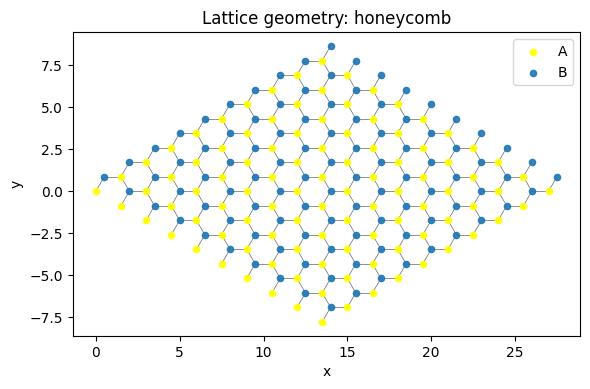

In [4]:
problem.plot(plot_type="lattice")

## Clebsch-Gordan Coefficients

In [7]:
tb = problem.hamiltonian[location]["tight_binding"] # Bulk

tb.CG_coefficients

{'|0,0;0.5,-0.5>': 0.707106781186548*sqrt(2),
 '|0,0;0.5,0.5>': 0.707106781186548*sqrt(2),
 '|1,-1;0.5,-0.5>': 1.00000000000000,
 '|1,-1;0.5,0.5>': 0.333333333333333*sqrt(3),
 '|1,0;0.5,-0.5>': 0.333333333333333*sqrt(6),
 '|1,0;0.5,0.5>': 0.333333333333333*sqrt(6),
 '|1,1;0.5,-0.5>': 0.333333333333333*sqrt(3),
 '|1,1;0.5,0.5>': 1.00000000000000}

In [8]:
tb.sublattice_data_dict["A"].keys()
sublattice = list(tb.sublattice_data_dict["A"].keys())[0]

## Coupled Angular Momentum States

In [ ]:
if location == "bulk":
    idx = tb.sublattice_data_dict["A"]["neighbour_idxs"][0]
    tb.sublattice_data_dict["A"]['coupled_states_dict'][idx]
elif location == "edge":
    idx = tb.sublattice_data_dict["A"][sublattice]["neighbour_idxs"][0]
    tb.sublattice_data_dict["A"][sublattice]['hopping_dict'][idx]

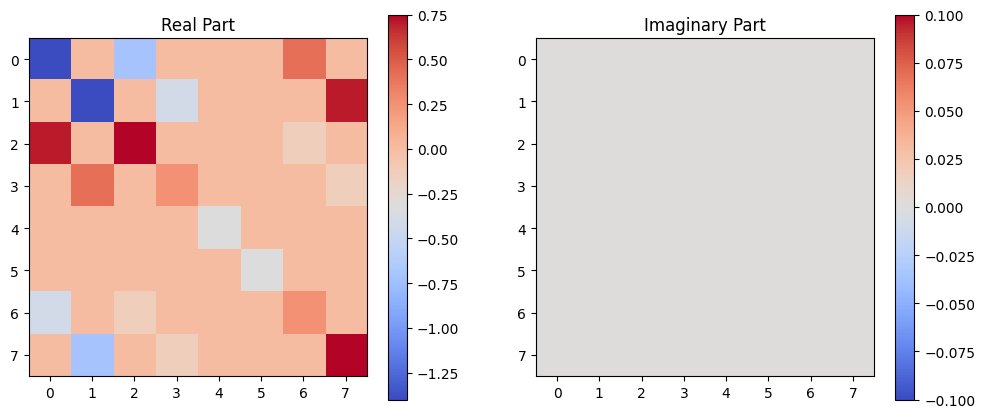

In [10]:
if location == "bulk":
    tb._visualise_matrix(tb.sublattice_data_dict["A"]['hopping_dict'][idx])
elif location == "edge":
    tb._visualise_matrix(tb.sublattice_data_dict["A"][sublattice]['hopping_dict'][idx])

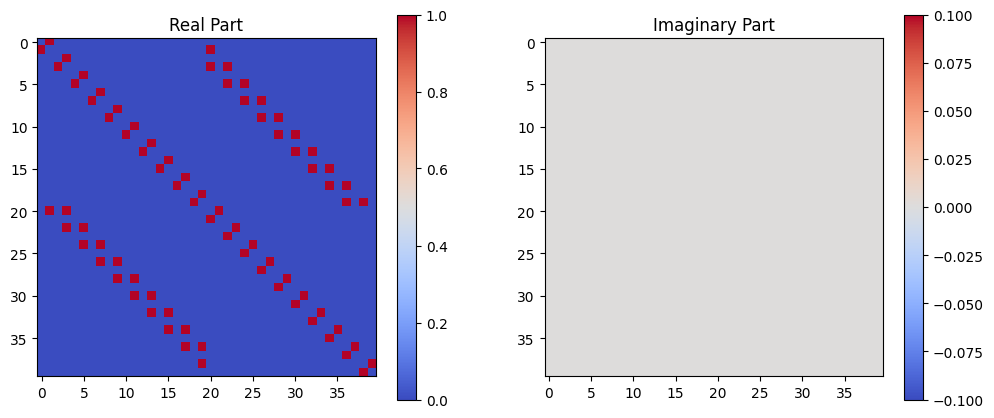

In [11]:
tb._visualise_matrix(tb.sublattice_connectivity)

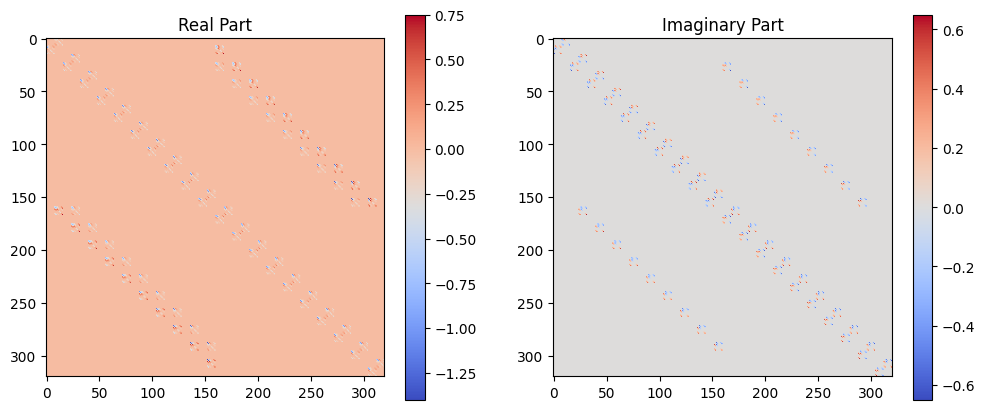

In [12]:
tb._visualise_matrix(tb.H)

In [13]:
problem.run(
    acceptor=False,
    H_type="real_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


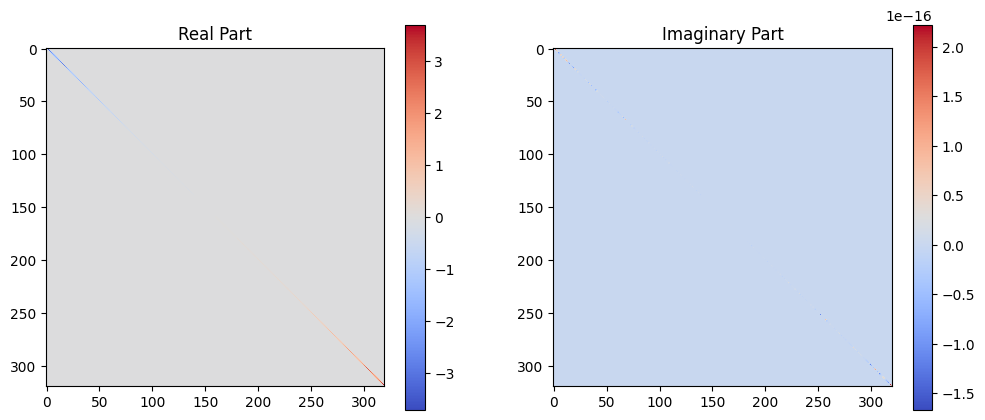

In [14]:
tb._visualise_matrix(tb.H_diag)

In [15]:
tb.E

array([-3.70147229, -3.70147229, -3.65024596, -3.65024596, -3.56755379,
       -3.56755379, -3.45739815, -3.45739815, -3.3253489 , -3.3253489 ,
       -3.1785833 , -3.1785833 , -3.02618717, -3.02618717, -2.88045953,
       -2.88045953, -2.76189703, -2.76189703, -2.45887772, -2.45887772,
       -2.16540303, -2.16540303, -2.10821141, -2.10821141, -2.03442505,
       -2.03442505, -1.96113227, -1.96113227, -1.89467394, -1.89467394,
       -1.83699447, -1.83699447, -1.78925738, -1.78925738, -1.75295177,
       -1.75295177, -1.72993876, -1.72993876, -1.62687835, -1.62687835,
       -1.3650775 , -1.3650775 , -1.30279473, -1.30279473, -1.26758565,
       -1.26758565, -1.21915349, -1.21915349, -1.16426677, -1.16426677,
       -1.10828474, -1.10828474, -1.05554259, -1.05554259, -1.00972803,
       -1.00972803, -0.97409376, -0.97409376, -0.95140025, -0.95140025,
       -0.79838959, -0.79838959, -0.77957613, -0.77957613, -0.7489932 ,
       -0.7489932 , -0.70780556, -0.70780556, -0.65765238, -0.65